# Laboratorium 9 - Sieci Rekurencyjne

Na tym laboratorium zapoznamy się z sieciami rekurencyjnymi - jedną z architektur dedykowanych danym sekwencyjnym. Dla danych sekwencyjnych, jednym z naturalnych podejść do modelowania jest założenie, że przetwarzając n-ty krok, możemy udostępnić modelowi pewną reprezentację historii/pamięci/stanu która w kompaktowy sposób przechowuje informację o "wszystkim co działo się wcześniej". W ten sposób zadania upraszcza sobie często np. modelowanie procesami stochastycznymi (założenie własności Markowa w modelu). W kontekście sieci neuronowych, odpowiednikiem takiego podejścia jest właśnie warstwa rekurencyjna: taka, która w n-tym kroku przetwarza n-te wejście i reprezentacje ukrytą z kroku n-1 (historię/stan/pamięć).

Oczywiście z góry warstwo wspomnieć o fakcie, że architektury rekurencyjne obecnie nie są pierwszym wyborem, w pracach state=of-the-art dominuje mechanizm uwagi. Transformery to obecnie podstawa wszystkiego, co kojarzone z sztuczną inteligencją - w szczególności wszelkiej maści "czatów" opartych o LLM (Large Language Models). Ale ich historia to w pierwszej kolejności dodanie mechanizmu uwagi do sieci rekurencyjnych, a dopiero potem spostrzeżenie, że po dodaniu tego mechanizmu, rekurencja nie jest już w zasadzie konieczna (bardzo znana publikacja *Attention Is All You Need*).

 Na tych laboratoriach przyjrzyjmy się warstwom LSTM - najpopularniejszej wersji architektury czysto rekurencyjnej.

# Zbiory danych

Przeprowadzimy test na dwóch zbiorach danych: klasyczny zbiór do analizy sentymentu tekstów (recenzje IMDB), oraz zbiór audio - rozpoznawanie owadów po wydawanych rzez nich odgłosach.

In [1]:
!pip install aeon

In [2]:
from tensorflow.keras.datasets import imdb
from aeon.datasets import load_classification
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_sequence, pad_sequence, pack_padded_sequence, pad_packed_sequence
from typing import Tuple
import torch.nn as nn
from tqdm import tqdm
from torch import optim
from matplotlib import pyplot as plt
from torch.nn.utils import clip_grad_norm_
from sklearn.manifold import TSNE
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

In [4]:
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [5]:
X, y = load_classification("InsectWingbeat", extract_path="insect_data")

C:\Users\48572\AppData\Local\Temp\ipykernel_22220\1855011621.py:1: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y = load_classification("InsectWingbeat", extract_path="insect_data")


In [6]:
print(X[0])

[[-5.2600e-04 -6.8000e-04 -1.0782e-02 ...  1.9104e-02 -1.8969e-02
  -9.8000e-04]
 [ 4.2600e-04  2.9300e-04  1.3112e-02 ... -9.1000e-05 -3.2437e-02
  -2.5000e-05]
 [-4.9000e-04 -4.4300e-04 -1.2667e-02 ... -9.7161e-01 -2.8844e-02
   9.1500e-04]
 ...
 [ 6.5200e-04  5.2600e-04 -2.0744e-02 ...  2.0344e-02 -4.3800e-03
   7.9350e-03]
 [-8.1800e-04  2.4800e-04  2.6454e-02 ...  2.0116e-02 -3.5250e-03
  -2.4500e-04]
 [-8.1800e-04  2.4800e-04  2.6454e-02 ...  2.0116e-02 -3.5250e-03
  -2.4500e-04]]


# Wczytywanie danych sekwencyjnych

Dla danych sekwencyjnych, przy przetwarzaniu w batchu pojawia się nowa komplikacja: batch musi być możliwy do "spakowania" w tensorze `batch_size x vector_dimension x sequence_length `, podczas gdy sekwencje w zbiorze uczącym nie muszą być jednakowego rozmiaru. Rozwiązaniem jest padding: dopełnianie tensorów zerami do stałej długości.

W problemach klasyfikacyjnych to powoduje jednak nowy problem: chcemy uzyskać reprezentację do klasyfikacji na końcu właściwej sekwencji, nie po przetworzeniu kilu (nastu/dziesięciu/set) dodatkowych wektorów zer. Implementacje warstw rekurencyjnych w torchu oferują nam rozwiązanie w postaci obiektów PackedSequence. Odpowiednimi funkcjami możemy "spakować" zarówno listę sekencji, jak i tensor już wypadowanych danych z podanymi osobno długościami sekwencji. Podanie takiej paczki na wejści warstwy rekurencyjnej gwarantuje, że warstwa zwróci nam swoją reprezentację na poziomie **ostatniego elementu właściwej sekwencji** (nie biorąc pod uwagę paddingu).

In [7]:
sequences = [[0,1,2,3],
             [0,1],
             [0]]

packed_sequences = pack_sequence([torch.tensor(seq) for seq in sequences])
print(packed_sequences)

padded_sequences = pad_sequence([torch.tensor(seq) for seq in sequences])
print(padded_sequences)

packed_padded_sequences = pack_padded_sequence(padded_sequences, [len(s) for s in sequences])
print(packed_padded_sequences)

PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)
tensor([[0, 0, 0],
        [1, 1, 0],
        [2, 0, 0],
        [3, 0, 0]])
PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)


# Zadanie 1

Zaimplementuj obiekty Dataset i DataLoader dla naszych zbiorów danych w wariantach zwracających zarówno obiekt PackedSequences, jak i prosty tensor z  wypadowanym zerami batchem.

In [8]:
# zaimplementuj DataLoader z wariantami: Padded sequences i standardowe tensory, dopełnione zerami do równej długości

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_padded(batch):
    sample = batch[0][0]

    is_sequence_of_vectors = (
        isinstance(sample, np.ndarray) and sample.ndim == 2
    ) or (
        torch.is_tensor(sample) and sample.dim() == 2
    )

    if is_sequence_of_vectors:
        sequences = [torch.tensor(item[0], dtype=torch.float32).t() for item in batch]
    else:
        sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]

    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)

    sequences_padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0
    )

    return sequences_padded, labels


def collate_packed(batch):
    sample = batch[0][0]

    is_sequence_of_vectors = (
        isinstance(sample, np.ndarray) and sample.ndim == 2
    ) or (
        torch.is_tensor(sample) and sample.dim() == 2
    )

    if is_sequence_of_vectors:
        sequences = [torch.tensor(item[0], dtype=torch.float32).t() for item in batch]
    else:
        sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]

    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0
    )

    packed = pack_padded_sequence(
        padded,
        lengths.cpu(),
        batch_first=True,
        enforce_sorted=False
    )

    return packed, labels

def to_dataloader(
        X_train: torch.Tensor,
        y_train: torch.Tensor,
        X_test: torch.Tensor,
        y_test: torch.Tensor,
        batch_size: int = 32,
        if_packed: bool = False,
) -> Tuple[DataLoader, DataLoader]:
    train_ds = SequenceDataset(X_train, y_train)
    test_ds = SequenceDataset(X_test, y_test)

    collate_fn = collate_packed if if_packed else collate_padded

    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        collate_fn=collate_fn
    )

    return train_dl, test_dl

# Embedding

Warstwy embeddingu są elementem wykorzystywanym przy przetwarzaniu danych, gdzie elementem jest id w pewnym dyskretnym zbiorze obiektów. Przykładowo, dla danych językowych może być to zbiór możliwych słów. Warstwa przyporządkowuje każdemu id jego własny wektor, i zakładamy, że w trakcie uczenia wyuczy się podobieństwa między obiektami.

## Model LSTM

W teorii, warstwy LSTM potrafią zapamiętywać "długoterminowo" a więc to skąd wyciągamy dane nie powinno robić większego problemu. Sprawdźmy czy tak jest w rzeczywistości, implementując wersję prostego eksperymentu - implementując uczenie zarówno z wykorzystaniem obiektów PackedSequence, jak i zwyczajnych tensorów dopełnionych zerami.

Nasz model LSTM musi być przygotowany na wszystkie opisane wersje naszego eksperymentu: dane w postaci sekwencji już w przestrzeni cech i w postaci sekwencji Integerów z embeddingiem w obrębie sieci; wykorzystanie PacekdSequences lub nie.

(**UWAGA:** W przypadku wykorzystania Embeddingu i Packed Sequences jednocześnie, będzie trzeba rozpakować, embedować i spakować jeszcze raz. Obsługiwanie tych czterech wariantów w jednej klasie nie jest praktyczne, potraktuj je raczej jako ćwiczenie.)
- https://www.datacamp.com/fr/tutorial/lstm-models

In [9]:
class LSTMNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, bidirectional=False, vocab_size=0, embed=False, packed=False):
        super(LSTMNet, self).__init__()
        self.bidirectional = bidirectional
        self.embed = embed
        self.packed = packed
        if self.embed and vocab_size > 0:
            self.embedding = nn.Embedding(vocab_size, input_size, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )
        fc_input_size = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Linear(fc_input_size, num_classes)

    def forward(self, x):
        if self.packed:
            if self.embed:
                x_padded, lengths = pad_packed_sequence(x, batch_first=True)
                x_embedded = self.embedding(x_padded.long())
                x = pack_padded_sequence(x_embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        elif self.embed:
            x = self.embedding(x.long())

        lstm_out, (h_n, c_n) = self.lstm(x)

        if self.bidirectional:
            h_final = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_final = h_n[-1]

        return self.fc(h_final)

## Uczenie

Pętla ucząca dla modelu LSTM będzie analogiczna do znanych nam wcześniej

In [10]:
def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> tuple[float, float]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch.cuda())
        batch_size = len(y_pred)
        all += batch_size

        loss += loss_fn(y_pred, y_batch.cuda()).item() * batch_size
        correct += count_correct(y_pred, y_batch.cuda())
    return loss / all, float(correct) / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True
):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  for epoch in range(epochs):
      model.train()
      for X_batch, y_batch in tqdm(train_dl):
          y_pred = model(X_batch.cuda())
          loss = loss_fn(y_pred, y_batch.cuda())

          loss.backward()
          clip_grad_norm_(model.parameters(), max_norm=5.0)
          optimiser.step()
          optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              history['train_loss'].append(train_loss)
              history['train_acc'].append(train_acc)
              history['val_loss'].append(val_loss)
              history['val_acc'].append(val_acc)
  return history

def plot_metrixes(all_histories):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    ax_train_loss = axes[0, 0]
    ax_val_loss = axes[0, 1]
    ax_train_acc = axes[1, 0]
    ax_val_acc = axes[1, 1]

    for name, hist in all_histories.items():
        train_loss = [float(x) for x in hist['train_loss']]
        val_loss = [float(x) for x in hist['val_loss']]
        train_acc = [float(x) for x in hist['train_acc']]
        val_acc = [float(x) for x in hist['val_acc']]

        ax_train_loss.plot(train_loss, label=name, linewidth=2)
        ax_val_loss.plot(val_loss, label=name, linewidth=2, linestyle='--')

        ax_train_acc.plot(train_acc, label=name, linewidth=2)
        ax_val_acc.plot(val_acc, label=name, linewidth=2, linestyle='--')

    ax_train_loss.set_title("Train Loss")
    ax_train_loss.set_xlabel("Epoch")
    ax_train_loss.set_ylabel("Loss")
    ax_train_loss.legend()
    ax_train_loss.grid(True, linestyle=':', alpha=0.6)

    ax_val_loss.set_title("Validation Loss")
    ax_val_loss.set_xlabel("Epoch")
    ax_val_loss.set_ylabel("Loss")
    ax_val_loss.legend()
    ax_val_loss.grid(True, linestyle=':', alpha=0.6)

    ax_train_acc.set_title("Train Accuracy")
    ax_train_acc.set_xlabel("Epoch")
    ax_train_acc.set_ylabel("Accuracy")
    ax_train_acc.legend()
    ax_train_acc.grid(True, linestyle=':', alpha=0.6)

    ax_val_acc.set_title("Validation Accuracy")
    ax_val_acc.set_xlabel("Epoch")
    ax_val_acc.set_ylabel("Accuracy")
    ax_val_acc.legend()
    ax_val_acc.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

## Zadanie 2

Przeprowadź uczenie modelu LSTM na zadanym zbiorze i porównaj następujące podejścia:

*   LSTM, dane z paddingiem do długości najdłuższej sekwencji w batchu
*   Jak wyżej, ale Bidirectional
*   LSTM (nie bidirectional) z wykorzystaniem obiektów PaddedSequences

In [11]:
max_train_index = max([max(sequence) for sequence in x_train])
max_test_index = max([max(sequence) for sequence in x_test])
vocab_size = max(max_train_index, max_test_index) + 1

In [12]:
imdb_configs = {
    "IMDB_Padded_Unidirectional": (
        LSTMNet(input_size=32, hidden_size=32, num_layers=1, num_classes=2, bidirectional=False, vocab_size=vocab_size, embed=True, packed=False),
        False
    ),
    "IMDB_Padded_Bidirectional": (
        LSTMNet(input_size=32, hidden_size=32, num_layers=1, num_classes=2, bidirectional=True, vocab_size=vocab_size, embed=True, packed=False),
        False
    ),
    "IMDB_Packed_Unidirectional": (
        LSTMNet(input_size=32, hidden_size=32, num_layers=1, num_classes=2, bidirectional=False, vocab_size=vocab_size, embed=True, packed=True),
        True
    )
}
all_histories = {}

for name, (model, is_packed) in imdb_configs.items():
    model = model.cuda()
    loss = torch.nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_dl, test_dl = to_dataloader(x_train, y_train, x_test, y_test, batch_size=64, if_packed=is_packed)

    history = fit(model, optimizer, loss, train_dl, test_dl, 25)
    all_histories[name] = history

100%|██████████| 391/391 [00:34<00:00, 11.46it/s]


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_ins, X_test_ins, y_train_ins, y_test_ins = train_test_split(
    X, y_encoded, test_size=0.2, random_state=113, stratify=y_encoded
)

input_size_ins = X_train_ins[0].shape[0]
num_classes_ins = len(np.unique(y_encoded))

insect_histories = {}

insect_configs = {
    "Insect_Padded_Unidirectional": (
        LSTMNet(input_size=input_size_ins, hidden_size=64, num_layers=1, num_classes=num_classes_ins, bidirectional=False, embed=False),
        False
    ),
    "Insect_Padded_Bidirectional": (
        LSTMNet(input_size=input_size_ins, hidden_size=64, num_layers=1, num_classes=num_classes_ins, bidirectional=True, embed=False),
        False
    ),
    "Insect_Packed_Unidirectional": (
        LSTMNet(input_size=input_size_ins, hidden_size=64, num_layers=1, num_classes=num_classes_ins, bidirectional=False, embed=False, packed=True),
        True
    )
}

for name, (model, is_packed) in insect_configs.items():
    model = model.cuda()

    train_dl, test_dl = to_dataloader(X_train_ins, y_train_ins, X_test_ins, y_test_ins, batch_size=32, if_packed=is_packed)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    history = fit(model, optimizer, loss_fn, train_dl, test_dl, epochs=25)
    all_histories[name] = history

100%|██████████| 1250/1250 [00:06<00:00, 203.55it/s]


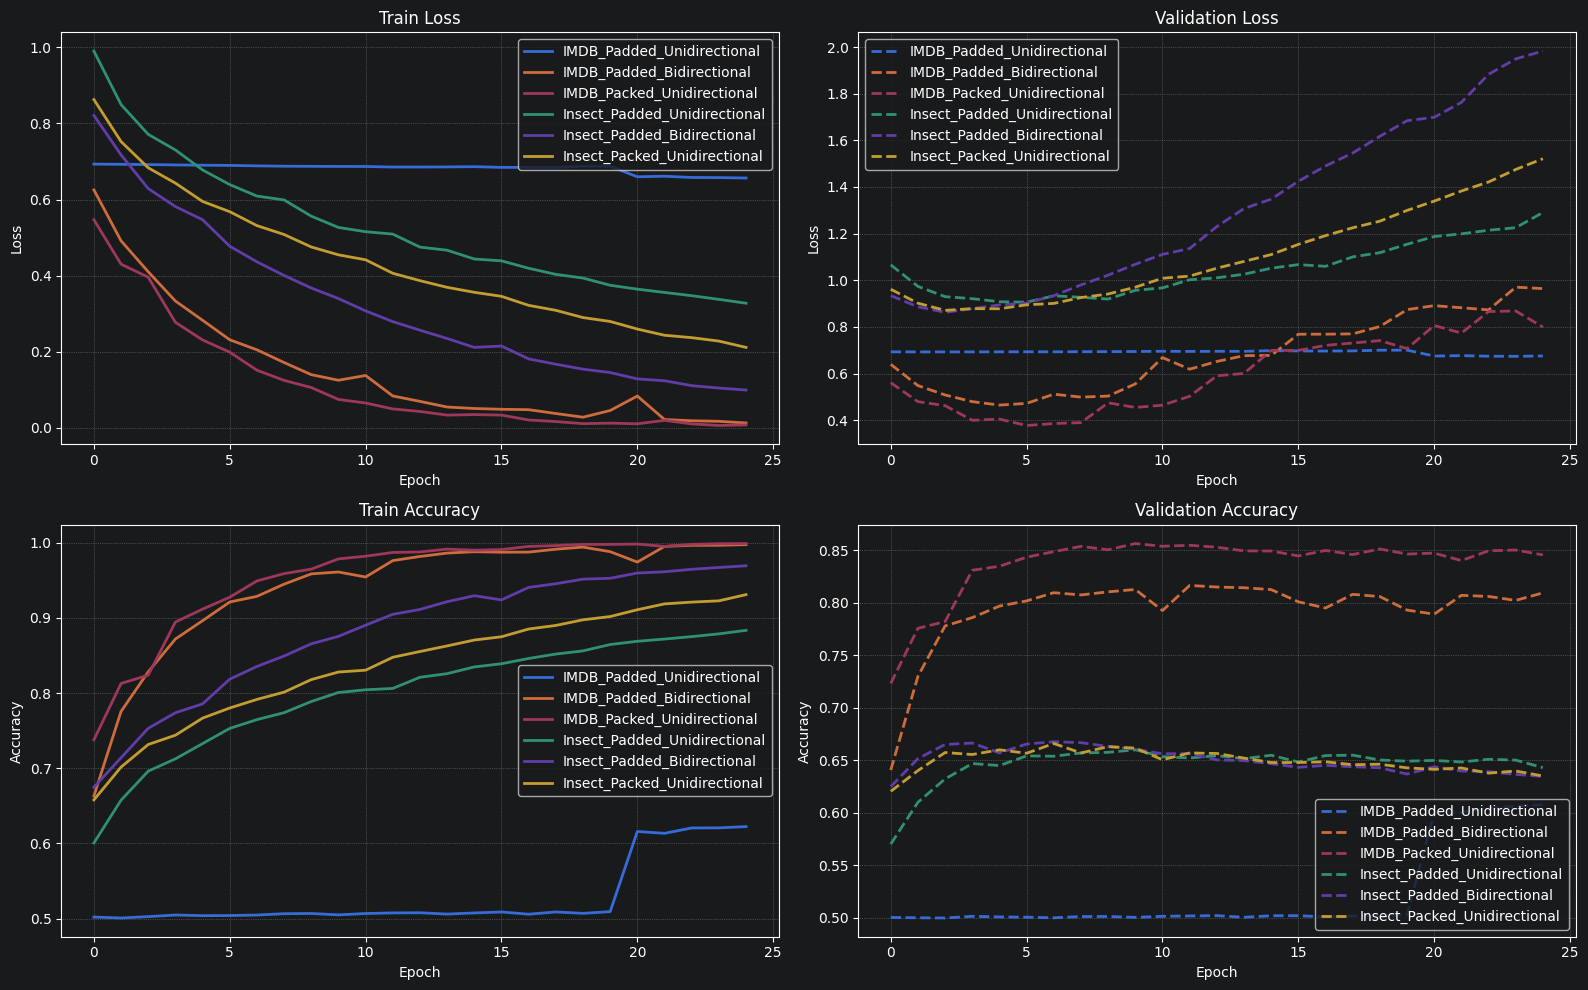

In [14]:
plot_metrixes(all_histories)

# Zadanie 3

Dla modelu językowego, dokonaj wizualizacji embeddingów 10 przykładowych słów. Dobierz słowa samodzielnie tak, aby pokazać, że embedding częściowo (ale prwadopodobnie nie idealnie) oddają relacje semantyczne. Możesz wykorzystać gotowe metody redukcji wymiarowości np. z scikit-learn aby umieścić embeddingi w przestrzeni dwuwymiarowej.
- https://sabber.medium.com/classifying-yelp-review-comments-using-lstm-and-word-embeddings-part-1-eb2275e4066b

Ponieważ zbiór pobierany z tf.keras jest już reprezentowany w postaci list liczb całkowitych, bedziesz korzystać ze słownika indeksów również dostępnego w tf.keras:

In [16]:
word_idx = imdb.get_word_index(
    path='imdb_word_index.json'
)
print(word_idx["good"])

model, is_packed = imdb_configs["IMDB_Padded_Unidirectional"]
embedding_weights = model.embedding.weight.data.cpu().numpy()

49


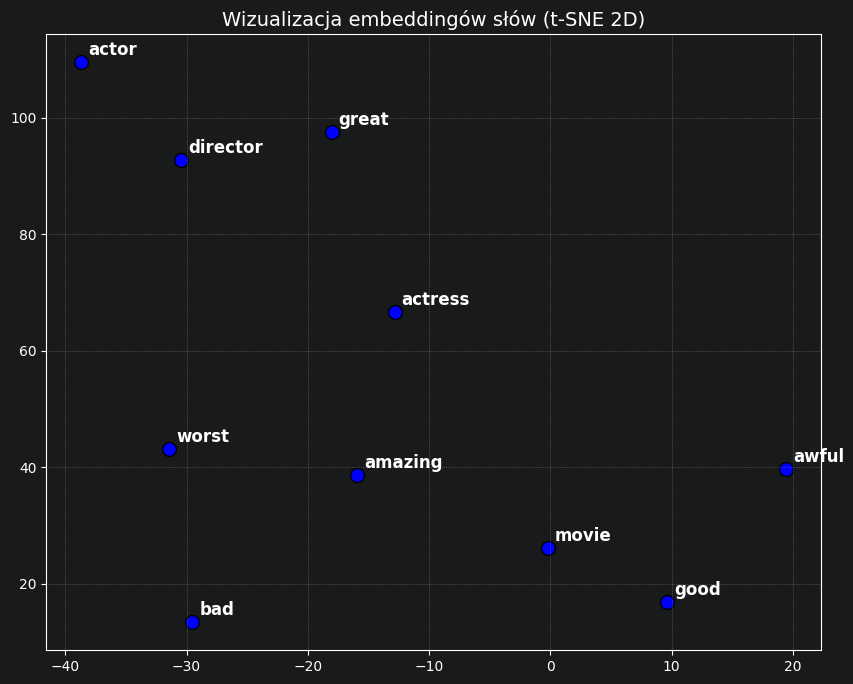

In [20]:
words_to_plot = ["good", "great", "amazing", "bad", "worst", "awful", "actor", "actress", "director", "movie"]

selected_indices = []
valid_words = []

for word in words_to_plot:
    if word in word_idx:
        idx = word_idx[word] + 3
        if idx < embedding_weights.shape[0]:
            selected_indices.append(idx)
            valid_words.append(word)

word_vectors = embedding_weights[selected_indices]
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
vectors_2d = tsne.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='blue', edgecolors='k', s=100)

for i, word in enumerate(valid_words):
    plt.annotate(
        word,
        xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Wizualizacja embeddingów słów (t-SNE 2D)", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()